In [1]:
import os
import zipfile

# ---------- Para Google Colab ----------
# from google.colab import drive

# drive.mount('/content/drive')

# # Cambia la ruta si tu ZIP se llama distinto
# RUTA_ZIP = '/content/drive/MyDrive/TrabajoFinal_PIA/dataset_robusto_crnn.zip'
# RUTA_DESTINO = '/content/dataset_local'
#--------------------------------------------

RUTA_ZIP = 'dataset_robusto_crnn.zip'
RUTA_DESTINO = 'dataset_local_crnn'
os.makedirs(RUTA_DESTINO, exist_ok=True)
with zipfile.ZipFile(RUTA_ZIP, 'r') as zip_ref:
    zip_ref.extractall(RUTA_DESTINO)
print("¡Descompresión completada!")

# Esta es la carpeta única que contiene todas las fotos
DIRECTORIO_DATOS = os.path.join(RUTA_DESTINO, 'dataset_robusto_crnn')

¡Descompresión completada!


### Generador de datos y division de datos



In [2]:
import cv2
import random
import numpy as np
from sklearn.model_selection import train_test_split

# Parametros globales
LETRAS_ALFABETO = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
NUM_CLASES = len(LETRAS_ALFABETO) + 1  # El + 1 es para el CTC
ANCHO_IMG = 620
ALTO_IMG = 128
BATCH_SIZE = 32

todas_las_rutas = [os.path.join(DIRECTORIO_DATOS, f) for f in os.listdir(DIRECTORIO_DATOS) if f.endswith('.jpg')]

rutas_train, rutas_temp = train_test_split(todas_las_rutas, test_size=0.2, random_state=42)
rutas_val, rutas_test = train_test_split(rutas_temp, test_size=0.5, random_state=42)

print(f"Train: {len(rutas_train)} | Val: {len(rutas_val)} | Test: {len(rutas_test)}")

Train: 7200 | Val: 900 | Test: 900


In [3]:
def generador_crnn(rutas_imagenes, batch_size):
    while True:
        random.shuffle(rutas_imagenes)
        for i in range(0, len(rutas_imagenes), batch_size):
            lote_rutas = rutas_imagenes[i : i + batch_size]

            X_imagenes, Y_etiquetas, long_entrada, long_etiqueta = [], [], [], []

            for ruta in lote_rutas:
                # Extraer la palabra del archivo (ej: "WIFI_0123.jpg" -> "WIFI")
                nombre_archivo = os.path.basename(ruta)
                palabra = nombre_archivo.split('_')[0]

                # Leer imagen de 620x128
                img = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE) / 255.0
                img = np.expand_dims(img.T, axis=-1)

                X_imagenes.append(img)
                Y_etiquetas.append([LETRAS_ALFABETO.index(l) for l in palabra])
                long_etiqueta.append(len(palabra))
                long_entrada.append(155) # 620px -> MaxPooling -> 155 pasos

            # Padding de etiquetas
            # Rellenamos las palabras cortas con -1 matemáticamente
            MAX_LEN = 5
            Y_etiquetas_pad = np.full((len(Y_etiquetas), MAX_LEN), -1)
            for j, etiq in enumerate(Y_etiquetas):
                Y_etiquetas_pad[j, :len(etiq)] = etiq

            entradas = {
                'imagen_entrada': np.array(X_imagenes),
                'etiquetas_reales': Y_etiquetas_pad,
                'input_len': np.array(long_entrada),
                'label_len': np.array(long_etiqueta)
            }

            # Arreglo de Keras 3
            salidas = np.zeros([len(X_imagenes)])
            yield entradas, salidas

In [4]:
gen_train = generador_crnn(rutas_train, BATCH_SIZE)
gen_val = generador_crnn(rutas_val, BATCH_SIZE)

### Arquitectura de la red

In [5]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Reshape, Bidirectional, LSTM, Dense, Lambda, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.backend import ctc_batch_cost
from tensorflow.keras.optimizers import Adam

def funcion_ctc(args):
    y_pred, etiquetas, input_len, label_len = args
    return ctc_batch_cost(etiquetas, y_pred, input_len, label_len)

entrada_imagen = Input(shape=(ANCHO_IMG, ALTO_IMG, 1), name='imagen_entrada')
etiquetas_reales = Input(name='etiquetas_reales', shape=[None], dtype='float32')
input_len = Input(name='input_len', shape=[1], dtype='int64')
label_len = Input(name='label_len', shape=[1], dtype='int64')

# CNN
x = Conv2D(32, (3, 3), activation='relu', padding='same')(entrada_imagen)
x = MaxPooling2D((2, 2))(x) # 620 -> 310
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x) # 310 -> 155
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D(pool_size=(1, 2))(x) # 155x16

# Aplanado
x = Reshape(target_shape=(155, 2048))(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.2)(x)

# RNN
x = Bidirectional(LSTM(128, return_sequences=True))(x)
x = Bidirectional(LSTM(64, return_sequences=True))(x)

#Salida
salida_prediccion = Dense(NUM_CLASES, activation='softmax', name='prediccion_softmax')(x)
salida_ctc = Lambda(funcion_ctc, output_shape=(1,), name='salida_ctc')([salida_prediccion, etiquetas_reales, input_len, label_len])

modelo_crnn = Model(inputs=[entrada_imagen, etiquetas_reales, input_len, label_len], outputs=salida_ctc)

def dummy_loss(y_true, y_pred):
  return y_pred

optimizador_seguro = Adam(learning_rate=0.001, clipnorm=1.0)
modelo_crnn.compile(optimizer=optimizador_seguro, loss=dummy_loss)
modelo_crnn.compile(optimizer='adam', loss=dummy_loss)

### Entrenamiento

In [6]:
early_stop = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=0.00001, verbose=1)

pasos_train = len(rutas_train) // BATCH_SIZE
pasos_val = len(rutas_val) // BATCH_SIZE

print("Comienza entrenamiento")
historial = modelo_crnn.fit(
    gen_train, steps_per_epoch=pasos_train,
    validation_data=gen_val, validation_steps=pasos_val,
    epochs=60,
    callbacks=[early_stop, reduce_lr]
)

Comienza entrenamiento
Epoch 1/60
225/225 ━━━━━━━━━━━━━━━━━━━━ 44s 156ms/step - loss: 21.2433 - val_loss: 14.5379 - learning_rate: 0.0010
Epoch 2/60
225/225 ━━━━━━━━━━━━━━━━━━━━ 33s 145ms/step - loss: 14.6907 - val_loss: 14.4951 - learning_rate: 0.0010
Epoch 3/60
225/225 ━━━━━━━━━━━━━━━━━━━━ 33s 148ms/step - loss: 14.6885 - val_loss: 14.5172 - learning_rate: 0.0010
Epoch 4/60
225/225 ━━━━━━━━━━━━━━━━━━━━ 34s 150ms/step - loss: 14.6885 - val_loss: 14.5397 - learning_rate: 0.0010
Epoch 5/60
225/225 ━━━━━━━━━━━━━━━━━━━━ 33s 145ms/step - loss: 14.6454 - val_loss: 14.4206 - learning_rate: 0.0010
Epoch 6/60
225/225 ━━━━━━━━━━━━━━━━━━━━ 33s 145ms/step - loss: 14.4882 - val_loss: 14.1416 - learning_rate: 0.0010
Epoch 7/60
225/225 ━━━━━━━━━━━━━━━━━━━━ 33s 148ms/step - loss: 14.2248 - val_loss: 13.7919 - learning_rate: 0.0010
Epoch 8/60
225/225 ━━━━━━━━━━━━━━━━━━━━ 32s 144ms/step - loss: 13.4841 - val_loss: 12.2774 - learning_rate: 0.0010
Epoch 9/60
225/225 ━━━━━━━━━━━━━━━━━━━━ 33s 145ms/step - 

### Guardar el modelo

In [ ]:
# modelo_crnn.save('/content/drive/MyDrive/TrabajoFinal_PIA/modelo_crnn_v2.h5')
# print("Modelo definitivo guardado.")

Modelo definitivo guardado.


### Gráficas de visualización

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import time
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model

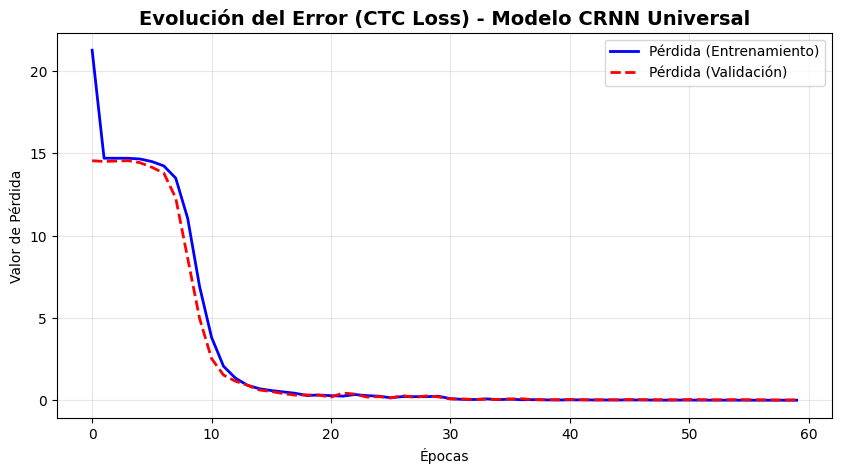

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(historial.history['loss'], label='Pérdida (Entrenamiento)', color='blue', linewidth=2)
plt.plot(historial.history['val_loss'], label='Pérdida (Validación)', color='red', linestyle='dashed', linewidth=2)

plt.title('Evolución del Error (CTC Loss) - Modelo CRNN Universal', fontsize=14, fontweight='bold')
plt.xlabel('Épocas')
plt.ylabel('Valor de Pérdida')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Evaluación del test

Carga del modelo guardado

In [9]:
RUTA_MODELO = 'modelo_crnn_v2.h5'

In [10]:
# Reconstrucción del modelo
entrada_imagen = Input(shape=(620, 128, 1), name='imagen_entrada')
etiquetas_reales = Input(name='etiquetas_reales', shape=[None], dtype='float32')
input_len = Input(name='input_len', shape=[1], dtype='int64')
label_len = Input(name='label_len', shape=[1], dtype='int64')

x = Conv2D(32, (3, 3), activation='relu', padding='same')(entrada_imagen)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D(pool_size=(1, 2))(x)

x = Reshape(target_shape=(155, 2048))(x)
x = Dense(256, activation='relu')(x)

x = Bidirectional(LSTM(128, return_sequences=True))(x)
x = Bidirectional(LSTM(64, return_sequences=True))(x)

salida_prediccion = Dense(27, activation='softmax', name='prediccion_softmax')(x)

def funcion_ctc(args):
    y_pred, etiquetas, input_len, label_len = args
    return K.ctc_batch_cost(etiquetas, y_pred, input_len, label_len)

salida_ctc = Lambda(funcion_ctc, output_shape=(1,), name='salida_ctc')(
    [salida_prediccion, etiquetas_reales, input_len, label_len]
)

modelo_completo = Model(inputs=[entrada_imagen, etiquetas_reales, input_len, label_len], outputs=salida_ctc)

In [11]:
# Carga del modelo
modelo_completo.load_weights(RUTA_MODELO)

In [12]:
entrada_limpia = modelo_completo.inputs[0]
salida_limpia = modelo_completo.get_layer('prediccion_softmax').output
modelo_inferencia = Model(inputs=entrada_limpia, outputs=salida_limpia)

correctas = 0
incorrectas = 0
errores_visuales = []
alfabeto = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

- Prueba de funcionamiento con test

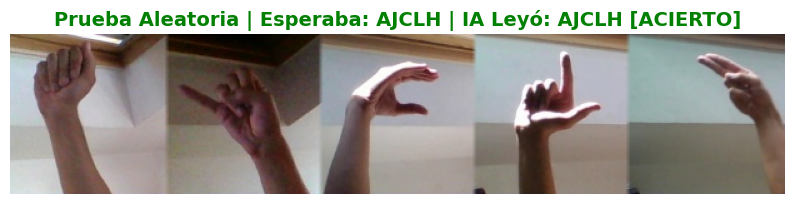

In [15]:
ruta_aleatoria = random.choice(rutas_test)

# Extraer la palabra
palabra_real = os.path.basename(ruta_aleatoria).split('_')[0]

# Procesar la imagen
img_bgr = cv2.imread(ruta_aleatoria)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
img_norm = img_gray / 255.0
img_batch = np.expand_dims(np.expand_dims(img_norm.T, axis=-1), axis=0)

pred = modelo_inferencia.predict(img_batch, verbose=0)
input_l = np.ones(pred.shape[0]) * pred.shape[1]
decoded = K.ctc_decode(pred, input_length=input_l, greedy=True)[0][0]
palabra_predicha = ""

for num in decoded[0]:
    if num != -1:
        palabra_predicha += alfabeto[int(num)]

es_correcta = (palabra_real == palabra_predicha)
color_titulo = 'green' if es_correcta else 'red'
texto_resultado = "ACIERTO" if es_correcta else "FALLO"

plt.figure(figsize=(10, 4))
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title(f"Prueba Aleatoria | Esperaba: {palabra_real} | IA Leyó: {palabra_predicha} [{texto_resultado}]",
          fontsize=14, color=color_titulo, fontweight='bold')
plt.axis('off')
plt.show()

- Errores cometidos

In [18]:
for i, ruta in enumerate(rutas_test):
    # En nuestro nuevo dataset, la palabra real es la primera parte del nombre (ej: "WIFI_0123.jpg" -> "WIFI")
    palabra_real = os.path.basename(ruta).split('_')[0]

    # Leemos la imagen (que ya mide 620x128 en este dataset)
    img = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
    img_norm = img / 255.0
    img_batch = np.expand_dims(np.expand_dims(img_norm.T, axis=-1), axis=0)

    # Predicción y decodificación
    pred = modelo_inferencia.predict(img_batch, verbose=0)
    input_len = np.ones(pred.shape[0]) * pred.shape[1]
    decoded = K.ctc_decode(pred, input_length=input_len, greedy=True)[0][0]

    palabra_predicha = ""
    for num in decoded[0]:
        if num != -1:
            palabra_predicha += alfabeto[int(num)]

    # Comprobación
    if palabra_real == palabra_predicha:
        correctas += 1
    else:
        incorrectas += 1
        # Guardamos un máximo de 5 errores para imprimirlos y analizarlos
        if len(errores_visuales) < 5:
            errores_visuales.append((img, palabra_real, palabra_predicha))

    # Progreso
    if (i + 1) % 100 == 0:
        print(f"  -> Procesadas {i + 1} de {len(rutas_test)} imágenes...")

precision = (correctas / len(rutas_test)) * 100

  -> Procesadas 100 de 900 imágenes...
  -> Procesadas 200 de 900 imágenes...
  -> Procesadas 300 de 900 imágenes...
  -> Procesadas 400 de 900 imágenes...
  -> Procesadas 500 de 900 imágenes...
  -> Procesadas 600 de 900 imágenes...
  -> Procesadas 700 de 900 imágenes...
  -> Procesadas 800 de 900 imágenes...
  -> Procesadas 900 de 900 imágenes...



 REPORTE FINAL DE RENDIMIENTO (CONJUNTO TEST)
Total imágenes evaluadas : 900
Aciertos                 : 1798
Fallos                   : 2
 PRECISIÓN (Accuracy)   : 199.78 %

 Muestra visual de fallos detectados:


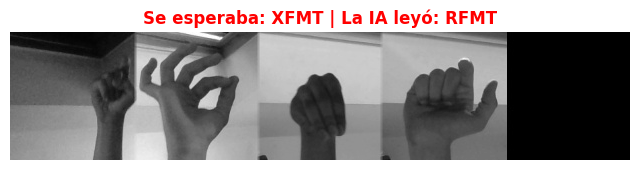

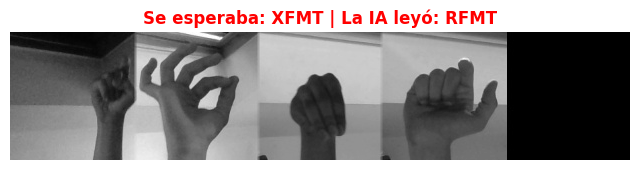

In [19]:
print("\n" + "="*50)
print(" REPORTE FINAL DE RENDIMIENTO (CONJUNTO TEST)")
print("="*50)
print(f"Total imágenes evaluadas : {len(rutas_test)}")
print(f"Aciertos                 : {correctas}")
print(f"Fallos                   : {incorrectas}")
print(f" PRECISIÓN (Accuracy)   : {precision:.2f} %")
print("="*50)

# Mostrar imágenes de fallos si los hay
if incorrectas > 0:
    print("\n Muestra visual de fallos detectados:")
    for img, real, predicha in errores_visuales:
        plt.figure(figsize=(8, 2))
        plt.imshow(img, cmap='gray')
        plt.title(f"Se esperaba: {real} | La IA leyó: {predicha}", color='red', fontweight='bold')
        plt.axis('off')
        plt.show()
else:
    print("\n¡INCREÍBLE! Pleno absoluto. La red no ha fallado ni una sola vez.")

### Pruebas de palabras reales

In [23]:
RUTA_PRUEBAS = 'dataset_pruebas'

In [24]:
#Procesamiento de la imagen
def preprocesar_tamano_variable(ruta_img, ancho_objetivo=620, alto_objetivo=128):
    img_bgr = cv2.imread(ruta_img)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    h, w = img_gray.shape
    
    if w > ancho_objetivo:
        img_adaptada = cv2.resize(img_gray, (ancho_objetivo, alto_objetivo))
    else:
        # Padding negro automático para palabras de 3 y 4 letras
        img_adaptada = np.zeros((alto_objetivo, ancho_objetivo), dtype=np.uint8)
        img_adaptada[:, :w] = img_gray 
        
    img_norm = img_adaptada / 255.0
    img_batch = np.expand_dims(np.expand_dims(img_norm.T, axis=-1), axis=0)
    
    return img_bgr, img_adaptada, img_batch

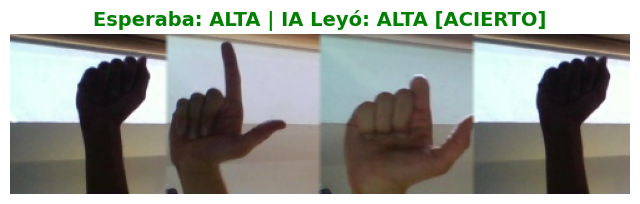

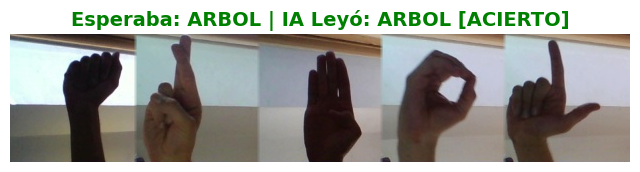

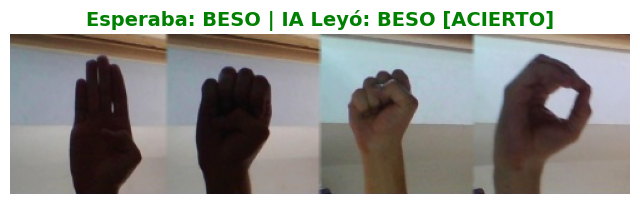

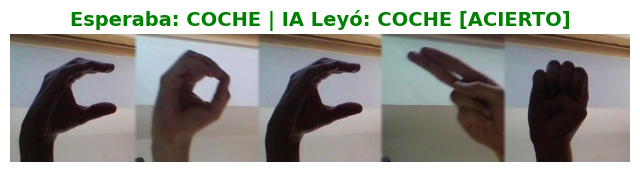

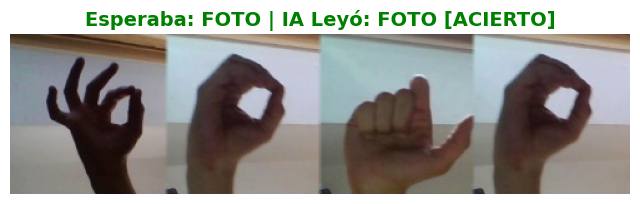

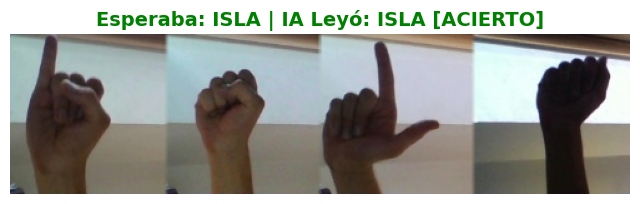

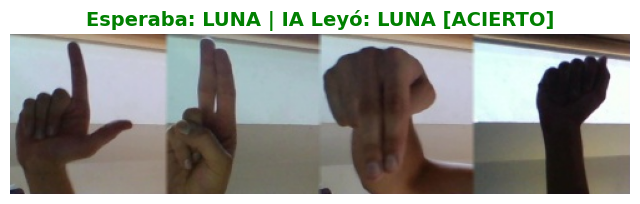

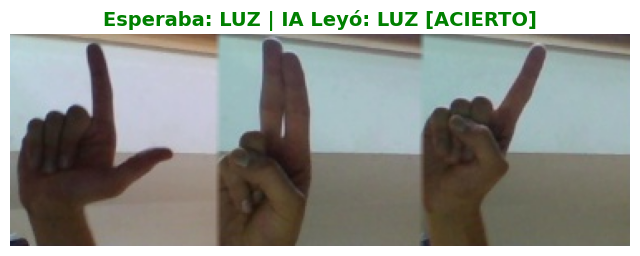

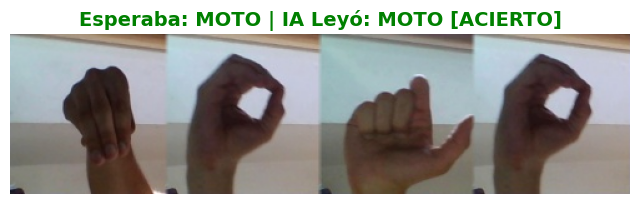

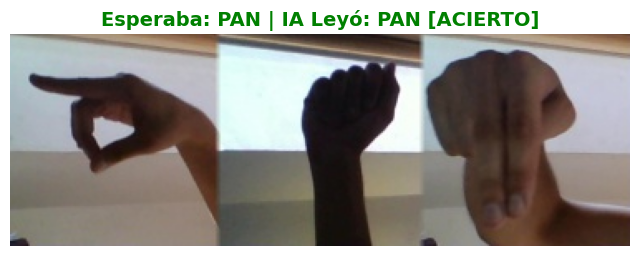

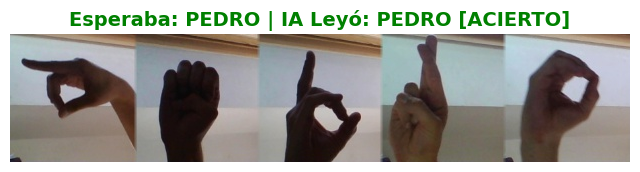

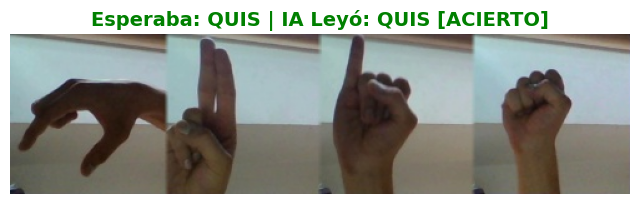

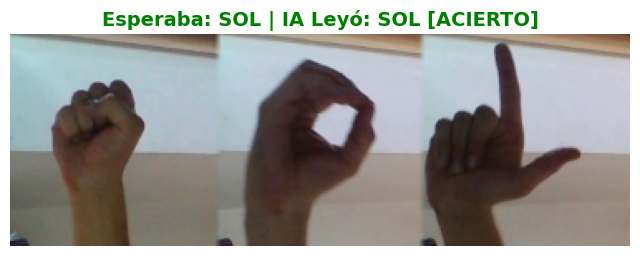

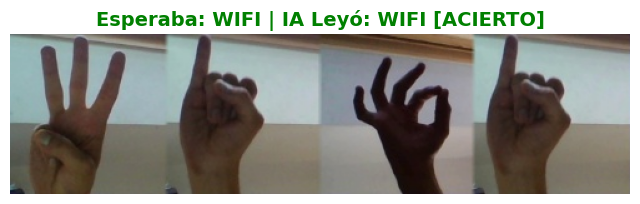


RESUMEN FINAL DE LA PRUEBA LOCAL
Total evaluadas: 14
Aciertos: 14
Precisión: 100.00%


In [25]:
# Evaluar todas las imagenes
rutas_evaluar = []
for carpeta in os.listdir(RUTA_PRUEBAS):
    ruta_carpeta = os.path.join(RUTA_PRUEBAS, carpeta)
    if os.path.isdir(ruta_carpeta):
        for archivo in os.listdir(ruta_carpeta):
            if archivo.endswith(('.jpg', '.png')):
                rutas_evaluar.append(os.path.join(ruta_carpeta, archivo))

correctas = 0
alfabeto = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"


# Procesar cada imagen
for ruta in rutas_evaluar:
    # La palabra real es el nombre de la subcarpeta (ej: "ALTA" extraído de "dataset_pruebas/ALTA/")
    palabra_real = os.path.basename(os.path.dirname(ruta))
    
    # Preprocesar
    img_original, img_bn_adaptada, img_batch = preprocesar_tamano_variable(ruta)
    
    # Predecir
    pred = modelo_inferencia.predict(img_batch, verbose=0)
    input_l = np.ones(pred.shape[0]) * pred.shape[1]
    decoded = K.ctc_decode(pred, input_length=input_l, greedy=True)[0][0]
    
    palabra_predicha = ""
    for num in decoded[0]:
        if num != -1:
            palabra_predicha += alfabeto[int(num)]
            
    # Resultados visuales
    es_correcta = (palabra_real == palabra_predicha)
    if es_correcta:
        correctas += 1
        color_titulo = 'green'
        texto = "ACIERTO"
    else:
        color_titulo = 'red'
        texto = "FALLO"
        
    # Mostrar la imagen original con el resultado superpuesto en pantalla
    plt.figure(figsize=(8, 3))
    plt.imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
    plt.title(f"Esperaba: {palabra_real} | IA Leyó: {palabra_predicha} [{texto}]", 
              fontsize=14, color=color_titulo, fontweight='bold')
    plt.axis('off')
    plt.show()

# Resumen final
print("\n" + "="*40)
print(f"RESUMEN FINAL DE LA PRUEBA LOCAL")
print("="*40)
print(f"Total evaluadas: {len(rutas_evaluar)}")
print(f"Aciertos: {correctas}")
print(f"Precisión: {(correctas/len(rutas_evaluar))*100:.2f}%")
print("="*40)